# Lab Instructions

You have been hired by James Cameron to create profiles of two characters for a reboot of the Titanic Movie: one that is most likely to survive the sinking and one that is least likely to survive.  Mr. Cameron wants this reboot to be as historically accurate as possible, so your profile of each character should be backed up with data and visualizations.

Each character profile should include information on their:
* Age
* Fare
* Sex
* Passenger class
* Travel companions (including both parents/children and siblings/spouse)
* Port of departure (indicated by the Embarked feature in the dataset)

For quantitative features like `Age` and `Fare`, you will need to use the `.loc` method we learned in class (or something similar) to place individuals in categories.  How you choose to do this is up to you, but make sure you explain your reasoning.

You should include at least one visualization for each element of the character profile (age, sex, passenger class, etc.) as evidence.

After you have developed your two character profiles, use your Pandas data wrangling skills to identify at least one real passenger in the dataset that fits each profile.  Print out the names of these individuals.  Look them up in [Encyclopeida Titanica](https://www.encyclopedia-titanica.org/) (or a similar resource).  

Tell Mr. Cameron at least one thing about the real passengers who fit your two character profiles that you learned from an external resource.  You need one interesting fact about a person who fits the profile of "most likely to survive" and one interesting fact about a person who fits the profile of "least likely to surivive".  



In [1]:
import pandas as pd
titanic_df = pd.read_csv("titanic_passengers.csv")
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
titanic_df['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

### Sex category

In [3]:
crosstab_sex = pd.crosstab(titanic_df['Sex'], titanic_df['Survived'], normalize = 'index') * 100
crosstab_sex

Survived,0,1
Sex,,
female,25.796178,74.203822
male,81.109185,18.890815


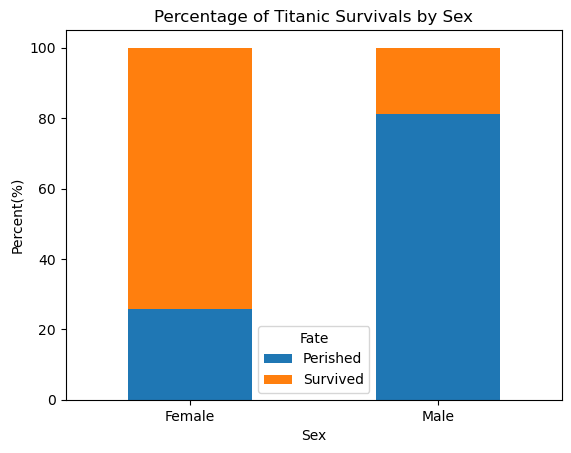

In [4]:
import matplotlib.pyplot as plt
crosstab_sex.plot(kind = 'bar', stacked = True)
plt.title("Percentage of Titanic Survivals by Sex")
plt.ylabel("Percent(%)")
plt.legend(["Perished", "Survived"], title = "Fate")
original_positions = [0,1]
new_labels = ["Female", "Male"]
plt.xticks(original_positions,new_labels, rotation = 0)
plt.show()

Looking at the data Female has the most chance to survive in Titanic while the Male has the least chance to survive

### Passenger Class category

In [5]:
crosstab_psc = pd.crosstab(titanic_df['Pclass'], titanic_df['Survived'], normalize = 'index') * 100
crosstab_psc

Survived,0,1
Pclass,,
1,37.037037,62.962963
2,52.717391,47.282609
3,75.763747,24.236253


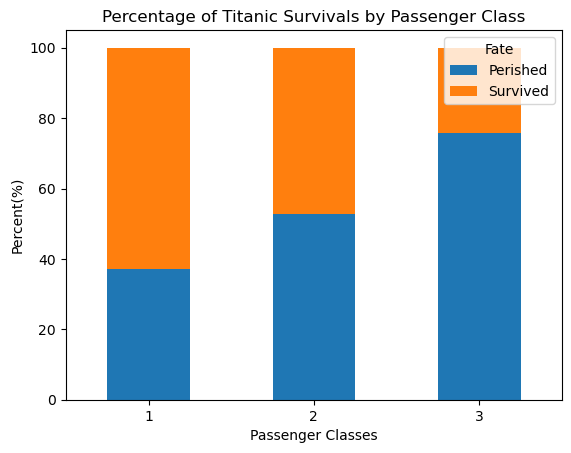

In [6]:

crosstab_psc.plot(kind = 'bar', stacked = True)
plt.title("Percentage of Titanic Survivals by Passenger Class")
plt.ylabel("Percent(%)")
plt.xlabel("Passenger Classes")
plt.legend(["Perished", "Survived"], title = "Fate")
original_positions = [0,1,2]
new_labels = ["1", "2", "3"]
plt.xticks(original_positions,new_labels, rotation = 0)
plt.show()

Looking at the bar chart, it's clear that person person that is in first class has highest chance to survive with 62% of them survive, and the least chance to survive is in third class with just 24% of them

### Travel Companions Category

In [7]:
titanic_df['SibSp'].describe()

count    891.000000
mean       0.523008
std        1.102743
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        8.000000
Name: SibSp, dtype: float64

In [8]:
pd.crosstab(titanic_df['SibSp'], titanic_df['Survived']) 

Survived,0,1
SibSp,,
0,398,210
1,97,112
2,15,13
3,12,4
4,15,3
5,5,0
8,7,0


Looking at the crosstable, the majority of passengers either traveled without any siblings or spouses, with very few having more than 2, and notably no one recorded with 6. To simplify the analysis, passengers were grouped into two categories: those with siblings/spouses on board and those without.

In [9]:
titanic_df.loc[titanic_df['SibSp'] == 0, 'SibSp_group'] = 'No siblings and spouses'
titanic_df.loc[titanic_df['SibSp'] > 0, 'SibSp_group'] = 'With sibling and spouse'

In [10]:
crosstab_sibsp = pd.crosstab(titanic_df['SibSp_group'], titanic_df['Survived'], normalize = 'index') * 100
crosstab_sibsp

Survived,0,1
SibSp_group,,
No siblings and spouses,65.460526,34.539474
With sibling and spouse,53.356890,46.643110


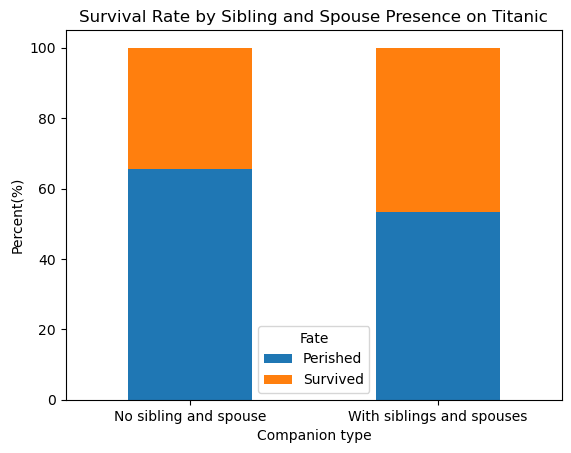

In [11]:
crosstab_sibsp.plot(kind = 'bar', stacked = True)
plt.title("Survival Rate by Sibling and Spouse Presence on Titanic")
plt.ylabel("Percent(%)")
plt.xlabel("Companion type")
plt.legend(["Perished", "Survived"], title = "Fate")
original_positions = [0,1]
new_labels = ["No sibling and spouse", 'With siblings and spouses']
plt.xticks(original_positions,new_labels, rotation = 0)
plt.show()

The group with siblings and spousrs has slightly more chance to survive than without companion

In [12]:
pd.crosstab(titanic_df['Parch'], titanic_df['Survived']) 

Survived,0,1
Parch,,
0,445,233
1,53,65
2,40,40
3,2,3
4,4,0
5,4,1
6,1,0


Looking at the crosstable, the majority of passengers either traveled without any parents or childrens, with very few having more than 2. To simplify the analysis, passengers were grouped into two categories: those with parents/childrens on board and those without.

In [13]:
titanic_df.loc[titanic_df['Parch'] == 0, 'Parche_group'] = 'No Parents and Childrens'
titanic_df.loc[titanic_df['Parch'] > 0, 'Parche_group'] = 'With Parent and Children'

In [14]:
crosstab_parche = pd.crosstab(titanic_df['Parche_group'], titanic_df['Survived'], normalize = 'index') * 100
crosstab_parche

Survived,0,1
Parche_group,,
No Parents and Childrens,65.634218,34.365782
With Parent and Children,48.826291,51.173709


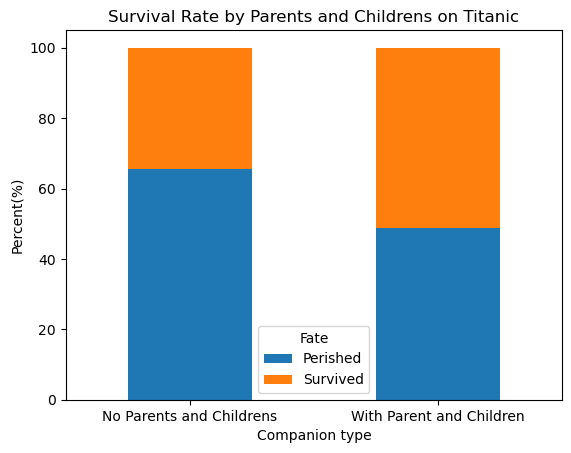

In [15]:
crosstab_parche.plot(kind = 'bar', stacked = True)
plt.title("Survival Rate by Parents and Childrens on Titanic")
plt.ylabel("Percent(%)")
plt.xlabel("Companion type")
plt.legend(["Perished", "Survived"], title = "Fate")
original_positions = [0,1]
new_labels = ["No Parents and Childrens", 'With Parent and Children']
plt.xticks(original_positions,new_labels, rotation = 0)
plt.show()

The group with parents and childrens has slightly more chance to survive than without companion

### Age

In [16]:
titanic_df['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

Age groups were divided into four categories — children (under 12), teenagers (12–17), adults (18–59), and seniors (60+) — based on commonly used demographic classifications.

In [17]:
titanic_df.loc[titanic_df['Age'] <= 12, 'Age_group'] = 'Childrens'
titanic_df.loc[(titanic_df['Age'] > 12) & 
               (titanic_df['Age'] <= 18), 'Age_group'] = 'Teenagers'
titanic_df.loc[(titanic_df['Age'] > 18) & 
               (titanic_df['Age'] <= 59), 'Age_group'] = 'Adult'
titanic_df.loc[(titanic_df['Age'] > 59) & 
               (titanic_df['Age'] <= 80), 'Age_group'] = 'Senior'

In [18]:
crosstab_age = pd.crosstab(titanic_df['Age_group'], titanic_df['Survived'], normalize = 'index') * 100
crosstab_age

Survived,0,1
Age_group,,
Adult,61.202186,38.797814
Childrens,42.028986,57.971014
Senior,73.076923,26.923077
Teenagers,57.142857,42.857143


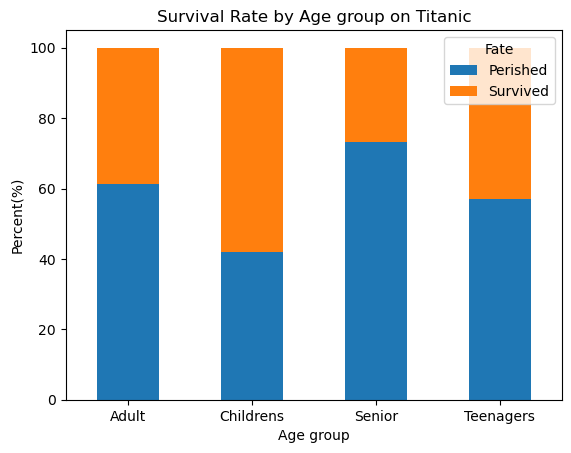

In [19]:
crosstab_age.plot(kind = 'bar', stacked = True)
plt.title("Survival Rate by Age group on Titanic")
plt.ylabel("Percent(%)")
plt.xlabel("Age group")
plt.legend(["Perished", "Survived"], title = "Fate")
plt.xticks(rotation = 0)
plt.show()

Children have the highest survival rate among all age groups, while seniors have the lowest.

### Fare

In [20]:
titanic_df['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

In [35]:
titanic_df['Fare'].median()

14.4542

For fare, passengers were split into two groups using the median as the threshold, separating higher-paying passengers from lower-paying ones.

In [22]:
titanic_df.loc[titanic_df['Fare'] <= titanic_df['Fare'].median(), 'Fare_group'] = 'Lower than median'
titanic_df.loc[titanic_df['Fare'] > titanic_df['Fare'].median(), 'Fare_group'] = 'Higher than median'

In [23]:
crosstab_fare = pd.crosstab(titanic_df['Fare_group'], titanic_df['Survived'], normalize = 'index') * 100
crosstab_fare

Survived,0,1
Fare_group,,
Higher than median,48.198198,51.801802
Lower than median,74.944072,25.055928


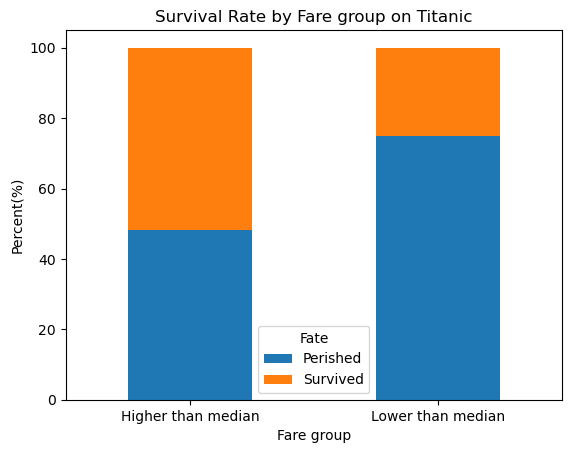

In [24]:
crosstab_fare.plot(kind = 'bar', stacked = True)
plt.title("Survival Rate by Fare group on Titanic")
plt.ylabel("Percent(%)")
plt.xlabel("Fare group")
plt.legend(["Perished", "Survived"], title = "Fate")
plt.xticks(rotation = 0)
plt.show()

In [29]:
crosstab_embark =  pd.crosstab(titanic_df['Embarked'], titanic_df['Survived'], normalize = 'index') * 100
crosstab_embark

Survived,0,1
Embarked,,
C,44.642857,55.357143
Q,61.038961,38.961039
S,66.304348,33.695652


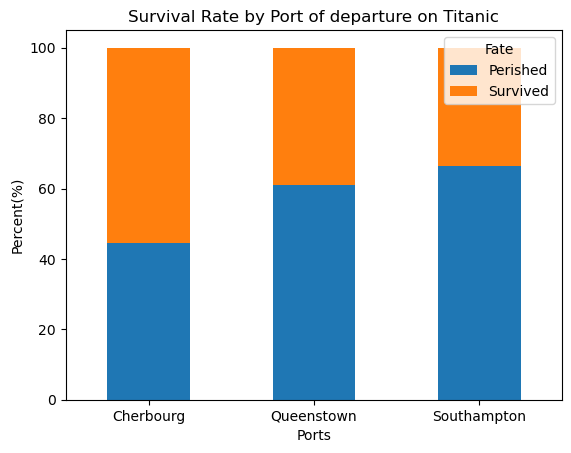

In [34]:
crosstab_embark.plot(kind = 'bar', stacked = True)
plt.title("Survival Rate by Port of departure on Titanic")
plt.ylabel("Percent(%)")
plt.xlabel("Ports")
plt.legend(["Perished", "Survived"], title = "Fate")
original_positions = [0,1,2]
new_labels = ['Cherbourg','Queenstown','Southampton']
plt.xticks(original_positions,new_labels,rotation = 0)
plt.show()

Passengers who embarked at Cherbourg had the highest survival rate among the three ports, while those who boarded at Southampton had the lowest

In [37]:
titanic_df.loc[(titanic_df['Sex'] == 'female') &
              (titanic_df['Pclass'] == 1) &
              (titanic_df['SibSp_group'] == 'With sibling and spouse') &
              (titanic_df['Parche_group'] == 'With Parent and Children') &
              (titanic_df['Age_group'] == 'Childrens') &
              (titanic_df['Fare_group'] == 'Lower than median')
]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,SibSp_group,Parche_group,Age_group,Fare_group
